# DNN

In [2]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report
from text_features import CombinedVectorizer, encode_labels, decode_labels
from ffnn import FFNN, evaluate_loss_accuracy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

N_CLASSES = 5

device: cuda
device: cuda


## *dados*

In [3]:
df_train = pd.read_csv('../datasets/dataset_v2_train.csv', sep=';')
df_test  = pd.read_csv('../datasets/dataset_v2_test.csv',  sep=';')
df_val   = pd.read_csv('../datasets/dataset_v2_val.csv',   sep=';')

print(f'treino: {len(df_train)} | teste: {len(df_test)} | val: {len(df_val)}')
print('\ndistribuição de treino:')
print(df_train['Label'].value_counts())

treino: 3500 | teste: 750 | val: 750

distribuição de treino:
Label
Meta         700
Anthropic    700
Openai       700
Google       700
Human        700
Name: count, dtype: int64


In [4]:
train_texts = df_train['Text'].fillna('').tolist()
test_texts  = df_test['Text'].fillna('').tolist()

# TF-IDF: palavra (1,2)-grams + char (3,5)-grams
vec = CombinedVectorizer(max_words=10000, ngram_range=(1,2),
                         max_chars=5000,  char_range=(3,5))

X_train = vec.fit_transform(train_texts)
X_test  = vec.transform(test_texts)

Y_train = encode_labels(df_train['Label'].tolist())
Y_test  = encode_labels(df_test['Label'].tolist())

print(f'dimensão das features: {X_train.shape[1]}')

dimensão das features: 15000


In [5]:
def make_loader(X, y, batch_size=64, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, Y_train, batch_size=32, shuffle=True)
test_loader  = make_loader(X_test,  Y_test,  batch_size=64)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')

X_train: (3500, 15000) | X_test: (750, 15000)


## *treino*

In [6]:
input_dim = X_train.shape[1]
model     = FFNN(input_dim=input_dim, n_classes=N_CLASSES,
                 topology=[512, 256, 128], dropout=0.4).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

NUM_EPOCHS = 200
PATIENCE   = 25

best_val_acc = 0.0
best_state   = None
no_improve   = 0

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss    = 0.0
    running_correct = 0
    running_total   = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * xb.size(0)
        preds            = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total   += yb.size(0)

    train_loss = running_loss / running_total
    train_acc  = running_correct / running_total
    val_loss, val_acc = evaluate_loss_accuracy(model, test_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'early stopping na epoch {epoch}')
            break

model.load_state_dict(best_state)
print(f'\nmelhor modelo -> val_acc={best_val_acc:.4f}')

Epoch 010/200 | train_loss=0.0013 | train_acc=1.0000 | val_loss=0.0100 | val_acc=0.9973
Epoch 020/200 | train_loss=0.0125 | train_acc=0.9960 | val_loss=0.0165 | val_acc=0.9960
Epoch 030/200 | train_loss=0.0136 | train_acc=0.9969 | val_loss=0.0007 | val_acc=1.0000
early stopping na epoch 33

melhor modelo -> val_acc=1.0000


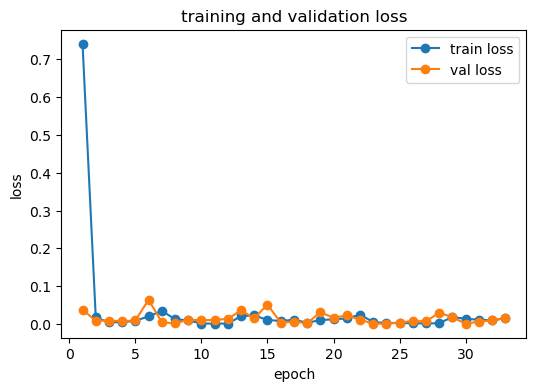

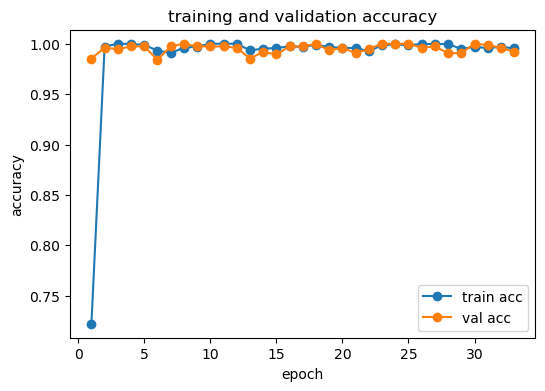

[TRAIN] accuracy=1.0000
[TEST]  accuracy=1.0000


In [7]:
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_losses, marker='o', label='train loss')
plt.plot(epochs_range, val_losses,   marker='o', label='val loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('training and validation loss')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs_range, train_accs, marker='o', label='train acc')
plt.plot(epochs_range, val_accs,   marker='o', label='val acc')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('training and validation accuracy')
plt.legend()
plt.show()

_, train_acc = evaluate_loss_accuracy(model, train_loader, criterion)
_, test_acc  = evaluate_loss_accuracy(model, test_loader,  criterion)
print(f'[TRAIN] accuracy={train_acc:.4f}')
print(f'[TEST]  accuracy={test_acc:.4f}')

In [8]:
torch.save(model.state_dict(), '../models/model_dnn_v2.pt')
with open('../vectorizers/vectorizer_dnn_v2.pkl', 'wb') as f:
    pickle.dump(vec, f)
print('modelo e vectorizer guardados.')

modelo e vectorizer guardados.


## *avaliação com dataset-exemplos*

In [9]:
df_ex = pd.read_csv('../datasets/dataset-exemplos.csv', sep=';')
X_ex  = vec.transform(df_ex['Text'].fillna('').tolist())
Y_ex  = encode_labels(df_ex['Label'].tolist())
ex_loader = make_loader(X_ex, Y_ex, batch_size=64)

model.eval()
preds_all = []
with torch.no_grad():
    for xb, _ in ex_loader:
        logits = model(xb.to(device))
        preds_all.extend(logits.argmax(dim=1).cpu().tolist())

preds_decoded = decode_labels(preds_all)
print(classification_report(
    df_ex['Label'].str.lower().tolist(),
    preds_decoded,
    digits=3
))

              precision    recall  f1-score   support

   anthropic      0.500     0.087     0.148        23
      google      0.308     0.250     0.276        16
       human      0.500     0.981     0.662        52
        meta      0.400     0.118     0.182        17
      openai      0.000     0.000     0.000        17

    accuracy                          0.472       125
   macro avg      0.342     0.287     0.254       125
weighted avg      0.394     0.472     0.363       125



## *avaliação com Subm1*

In [10]:
df_subm1     = pd.read_csv('../Subm1/subm1_labels_revealed.csv', sep=';')
X_subm1      = vec.transform(df_subm1['Text'].fillna('').tolist())
Y_subm1      = encode_labels(df_subm1['Label'].tolist())
subm1_loader = make_loader(X_subm1, Y_subm1, batch_size=64)

model.eval()
preds_all = []
with torch.no_grad():
    for xb, _ in subm1_loader:
        logits = model(xb.to(device))
        preds_all.extend(logits.argmax(dim=1).cpu().tolist())

preds_decoded = decode_labels(preds_all)
print(classification_report(
    df_subm1['Label'].str.lower().tolist(),
    preds_decoded,
    digits=3
))

              precision    recall  f1-score   support

   anthropic      0.800     0.235     0.364        17
      google      0.579     0.647     0.611        17
       human      0.604     0.941     0.736        34
        meta      0.692     0.500     0.581        18
      openai      0.300     0.214     0.250        14

    accuracy                          0.590       100
   macro avg      0.595     0.508     0.508       100
weighted avg      0.606     0.590     0.555       100

